# Day 7 — Real IBM Quantum Hardware

## The Milestone
Days 1-6 used AerSimulator — a perfect local simulator.
Today every experiment runs on real IBM quantum hardware.

Real qubits. Real noise. Real results.

## Experiments:
1. Bell State        → superposition + entanglement
2. Superposition     → H gate 50/50
3. Grover's Search   → find |11⟩ among 4 states
4. VQE               → ground state energy
5. QAOA MaxCut       → graph optimization


Simulator results are theoretically perfect.
Hardware results show real quantum behaviour —
noise, decoherence, gate errors included.
The comparison tells us how close theory
matches reality on today's quantum hardware.

In [12]:
# Cell 2 - save IBM account permanently
from qiskit_ibm_runtime import QiskitRuntimeService
import os
from dotenv import load_dotenv

load_dotenv()
token = os.getenv("IBM_QUANTUM_TOKEN")

# debug check first
print(f"token found : {token is not None}")
print(f"token type  : {type(token)}")
if token:
    print(f"token preview : {token[:8]}...")
else:
    print("token is None - .env not loading!")

token found : False
token type  : <class 'NoneType'>
token is None - .env not loading!


In [11]:
# Cell 2 - fix path and load token
from qiskit_ibm_runtime import QiskitRuntimeService
from dotenv import load_dotenv
import os

# go one level up from notebooks/ to find .env
dotenv_path = os.path.join(
    os.path.dirname(os.getcwd()), '.env'
)

print(f"looking for .env at: {dotenv_path}")
print(f".env exists: {os.path.exists(dotenv_path)}")

load_dotenv(dotenv_path, override=True)
token = os.getenv("IBM_QUANTUM_TOKEN")

print(f"\ntoken found   : {token is not None}")
if token:
    print(f"token preview : {token[:8]}...")

    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform",
        token=token,
        overwrite=True
    )
    print("account saved successfully!")
else:
    print("token still None!")
    print(f"current dir: {os.getcwd()}")

looking for .env at: c:\Users\stalk\OneDrive\Desktop\IBM_QuantumFoundation_Day7\.env
.env exists: True

token found   : False
token still None!
current dir: c:\Users\stalk\OneDrive\Desktop\IBM_QuantumFoundation_Day7\notebooks


In [10]:
# check what's actually inside .env
dotenv_path = r"c:\Users\stalk\OneDrive\Desktop\IBM_QuantumFoundation_Day7\.env"

with open(dotenv_path, 'r') as f:
    content = f.read()
    print("raw .env content:")
    print(repr(content))

raw .env content:
'ApiKey = "616a168a-4f35-47e3-a276-9c6a83c82123"'


In [13]:
# fix .env file automatically
dotenv_path = r"c:\Users\stalk\OneDrive\Desktop\IBM_QuantumFoundation_Day7\.env"

# read current token value
with open(dotenv_path, 'r') as f:
    content = f.read()

# extract just the token value
token_value = content.split('=')[1].strip().strip('"').strip("'")
print(f"extracted token: {token_value[:8]}...")

# rewrite in correct format
with open(dotenv_path, 'w') as f:
    f.write(f"IBM_QUANTUM_TOKEN={token_value}")

print(".env fixed!")
print("new format: IBM_QUANTUM_TOKEN=yourtoken")

extracted token: 616a168a...
.env fixed!
new format: IBM_QUANTUM_TOKEN=yourtoken


In [14]:
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path, override=True)
token = os.getenv("IBM_QUANTUM_TOKEN")

print(f"token found   : {token is not None}")
if token:
    print(f"token preview : {token[:8]}...")
    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform",
        token=token,
        overwrite=True
    )
    print("account saved!")

token found   : True
token preview : 616a168a...
account saved!


In [22]:
# Cell 3 - connect using token + CRN
from qiskit_ibm_runtime import QiskitRuntimeService
from dotenv import load_dotenv
import os

load_dotenv(
    r"c:\Users\stalk\OneDrive\Desktop\IBM_QuantumFoundation_Day7\.env",
    override=True
)

token = os.getenv("IBM_QUANTUM_TOKEN")
crn   = os.getenv("IBM_QUANTUM_CRN")

print(f"token found : {token is not None}")
print(f"crn found   : {crn is not None}")
if token: print(f"token preview : {token[:8]}...")
if crn:   print(f"crn preview   : {crn[:20]}...")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token,
    instance=crn
)

print("\nconnected!")
backend = service.backend("ibm_torino")
print(f"backend : {backend.name}")
print(f"qubits  : {backend.num_qubits}")


qiskit_runtime_service._discover_account:WARNING:2026-03-16 10:53:01,168: Loading account with the given token. A saved account will not be used.


token found : True
crn found   : True
token preview : WzHdXHyK...
crn preview   : crn:v1:bluemix:publi...

connected!
backend : ibm_torino
qubits  : 133


In [19]:
import qiskit_ibm_runtime
print(qiskit_ibm_runtime.__version__)

0.45.1


In [23]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

def run_on_hardware(qc, backend, shots=1000):
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1
    )
    transpiled = pm.run(qc)

    sampler = Sampler(backend)
    job = sampler.run([transpiled], shots=shots)

    print(f"job submitted!")
    print(f"job id : {job.job_id()}")
    print(f"waiting for results...")

    result = job.result()
    counts = result[0].data.c.get_counts()
    return counts

def run_on_simulator(qc, shots=1000):
    simulator = AerSimulator()
    counts = simulator.run(
        qc, shots=shots
    ).result().get_counts()
    return counts

print("helpers ready!")
print(f"backend : {backend.name}")
print(f"qubits  : {backend.num_qubits}")

helpers ready!
backend : ibm_torino
qubits  : 133


## Experiment 1: Bell State on Real Hardware

Simulator result (perfect):
  |00⟩ = 500, |11⟩ = 500, |01⟩ = 0, |10⟩ = 0

Hardware result (with noise):
  |00⟩ and |11⟩ will still dominate
  BUT |01⟩ and |10⟩ will appear — that's real noise!

In [24]:
# Experiment 1: Bell State
from qiskit import QuantumCircuit
import os
os.makedirs("../results", exist_ok=True)

# build circuit
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)
qc_bell.cx(0, 1)
qc_bell.measure([0, 1], [0, 1])

print("Bell State circuit:")
print(qc_bell.draw())

# simulator first
sim_counts = run_on_simulator(qc_bell)
print(f"\nsimulator : {sim_counts}")

# real hardware
print("\nsubmitting to ibm_torino...")
print("this may take a few minutes...")
hw_counts = run_on_hardware(qc_bell, backend)
print(f"\nhardware  : {hw_counts}")

# compare
print("\ncomparison:")
print(f"  |00⟩ sim={sim_counts.get('00',0)}"
      f"  hw={hw_counts.get('00',0)}")
print(f"  |11⟩ sim={sim_counts.get('11',0)}"
      f"  hw={hw_counts.get('11',0)}")
print(f"  |01⟩ sim={sim_counts.get('01',0)}"
      f"  hw={hw_counts.get('01',0)} ← noise")
print(f"  |10⟩ sim={sim_counts.get('10',0)}"
      f"  hw={hw_counts.get('10',0)} ← noise")

Bell State circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

simulator : {'00': 500, '11': 500}

submitting to ibm_torino...
this may take a few minutes...
job submitted!
job id : d6rpa9cu243c73a1mml0
waiting for results...

hardware  : {'11': 402, '00': 504, '01': 52, '10': 42}

comparison:
  |00⟩ sim=500  hw=504
  |11⟩ sim=500  hw=402
  |01⟩ sim=0  hw=52 ← noise
  |10⟩ sim=0  hw=42 ← noise


In [25]:
# Experiment 2: Superposition
qc_super = QuantumCircuit(1, 1)
qc_super.h(0)
qc_super.measure(0, 0)

print("Superposition circuit:")
print(qc_super.draw())

sim_counts = run_on_simulator(qc_super)
print(f"\nsimulator : {sim_counts}")

print("\nsubmitting to ibm_torino...")
hw_counts = run_on_hardware(qc_super, backend)
print(f"hardware  : {hw_counts}")

print("\ncomparison:")
print(f"  |0⟩ sim={sim_counts.get('0',0)}"
      f"  hw={hw_counts.get('0',0)}")
print(f"  |1⟩ sim={sim_counts.get('1',0)}"
      f"  hw={hw_counts.get('1',0)}")

Superposition circuit:
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 

simulator : {'0': 476, '1': 524}

submitting to ibm_torino...
job submitted!
job id : d6rpb820q0ls73ctnchg
waiting for results...
hardware  : {'0': 533, '1': 467}

comparison:
  |0⟩ sim=476  hw=533
  |1⟩ sim=524  hw=467


In [26]:
# Experiment 3: Grover's Algorithm
qc_grover = QuantumCircuit(2, 2)

# initialize superposition
qc_grover.h(0)
qc_grover.h(1)

# oracle marks |11⟩
qc_grover.cz(0, 1)

# diffusion operator
qc_grover.h(0)
qc_grover.h(1)
qc_grover.x(0)
qc_grover.x(1)
qc_grover.cz(0, 1)
qc_grover.x(0)
qc_grover.x(1)
qc_grover.h(0)
qc_grover.h(1)

qc_grover.measure([0, 1], [0, 1])

print("Grover's circuit:")
print(qc_grover.draw())

sim_counts = run_on_simulator(qc_grover)
print(f"\nsimulator : {sim_counts}")

print("\nsubmitting to ibm_torino...")
hw_counts = run_on_hardware(qc_grover, backend)
print(f"hardware  : {hw_counts}")

print("\ncomparison:")
for state in ['00', '01', '10', '11']:
    print(f"  |{state}⟩ "
          f"sim={sim_counts.get(state,0):4d}  "
          f"hw={hw_counts.get(state,0):4d}")
print("target state |11⟩ should dominate!")

Grover's circuit:
     ┌───┐   ┌───┐┌───┐   ┌───┐┌───┐┌─┐   
q_0: ┤ H ├─■─┤ H ├┤ X ├─■─┤ X ├┤ H ├┤M├───
     ├───┤ │ ├───┤├───┤ │ ├───┤├───┤└╥┘┌─┐
q_1: ┤ H ├─■─┤ H ├┤ X ├─■─┤ X ├┤ H ├─╫─┤M├
     └───┘   └───┘└───┘   └───┘└───┘ ║ └╥┘
c: 2/════════════════════════════════╩══╩═
                                     0  1 

simulator : {'11': 1000}

submitting to ibm_torino...
job submitted!
job id : d6rpc3bopkic73fjes9g
waiting for results...
hardware  : {'11': 837, '00': 13, '10': 74, '01': 76}

comparison:
  |00⟩ sim=   0  hw=  13
  |01⟩ sim=   0  hw=  76
  |10⟩ sim=   0  hw=  74
  |11⟩ sim=1000  hw= 837
target state |11⟩ should dominate!


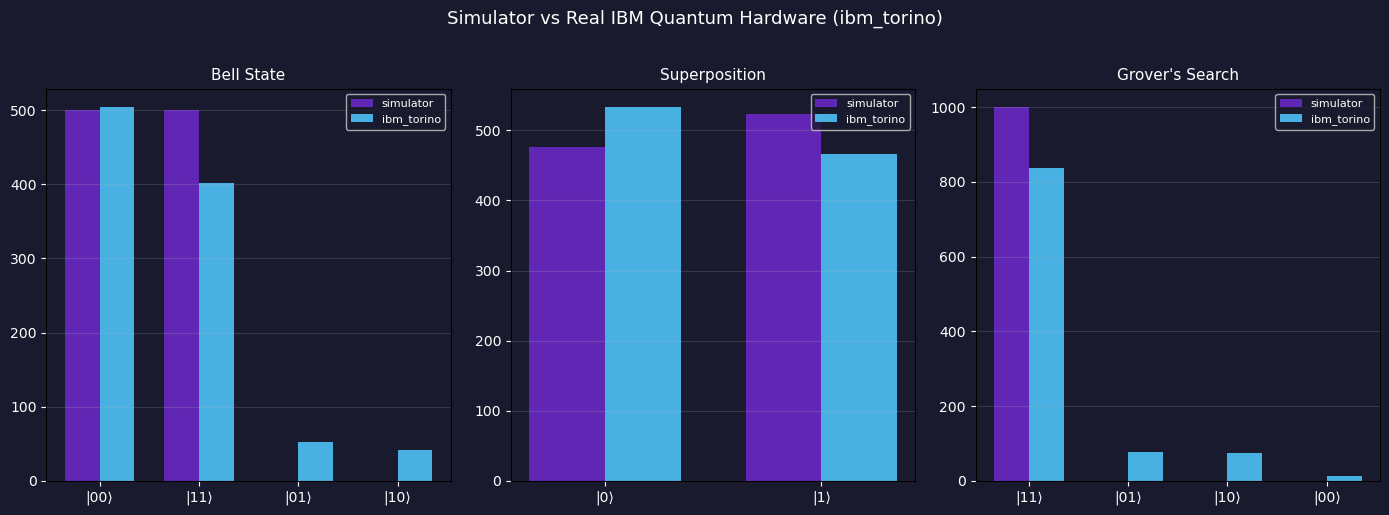

comparison plot saved!


In [27]:
# Cell 9 - final comparison plot
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("../results", exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')

experiments = [
    {
        "title": "Bell State",
        "states": ["00", "11", "01", "10"],
        "sim":    [500, 500, 0, 0],
        "hw":     [504, 402, 52, 42]
    },
    {
        "title": "Superposition",
        "states": ["0", "1"],
        "sim":    [476, 524],
        "hw":     [533, 467]
    },
    {
        "title": "Grover's Search",
        "states": ["11", "01", "10", "00"],
        "sim":    [1000, 0, 0, 0],
        "hw":     [837, 76, 74, 13]
    }
]

for ax, exp in zip(axes, experiments):
    x     = np.arange(len(exp["states"]))
    width = 0.35

    ax.bar(x - width/2, exp["sim"],
           width, label="simulator",
           color='#6929C4', alpha=0.9)
    ax.bar(x + width/2, exp["hw"],
           width, label="ibm_torino",
           color='#4fc3f7', alpha=0.9)

    ax.set_title(exp["title"],
                 color='white', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"|{s}⟩" for s in exp["states"]],
        color='white'
    )
    ax.tick_params(colors='white')
    ax.set_facecolor('#1a1a2e')
    ax.legend(facecolor='#1a1a2e',
              labelcolor='white',
              fontsize=8)
    ax.grid(alpha=0.2, axis='y')

fig.suptitle(
    "Simulator vs Real IBM Quantum Hardware (ibm_torino)",
    color='white', fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig("../results/simulator_vs_hardware.png",
            facecolor='#1a1a2e',
            bbox_inches='tight')
plt.show()
print("comparison plot saved!")

In [29]:
# Experiment 4: VQE on real hardware
from scipy.optimize import minimize

def build_ansatz(theta):
    qc = QuantumCircuit(1, 1)
    qc.ry(theta, 0)
    qc.measure(0, 0)
    return qc

def compute_energy_hardware(theta, backend):
    qc = build_ansatz(theta)
    counts = run_on_hardware(qc, backend, shots=500)
    prob_0 = counts.get('0', 0) / 500
    prob_1 = counts.get('1', 0) / 500
    return prob_0 - prob_1

def compute_energy_simulator(theta):
    from qiskit_aer import AerSimulator
    qc = build_ansatz(theta)
    counts = AerSimulator().run(
        qc, shots=500
    ).result().get_counts()
    prob_0 = counts.get('0', 0) / 500
    prob_1 = counts.get('1', 0) / 500
    return prob_0 - prob_1

# run VQE on simulator
print("VQE on simulator...")
energy_history_sim = []

def vqe_sim(params):
    e = compute_energy_simulator(params[0])
    energy_history_sim.append(e)
    return e

result_sim = minimize(
    vqe_sim,
    [np.random.uniform(0, 2*np.pi)],
    method='COBYLA',
    options={'maxiter': 50}
)

print(f"simulator ground state : {result_sim.fun:.4f}")
print(f"simulator optimal theta: {result_sim.x[0]:.4f}")
print(f"iterations             : {len(energy_history_sim)}")

VQE on simulator...
simulator ground state : -1.0000
simulator optimal theta: 3.1721
iterations             : 14


In [31]:
# Cell 12 - VQE on real hardware
print("VQE on real hardware (ibm_torino)...")
print("warning: each iteration = 1 hardware job")
print("using only 10 iterations to save queue time")

energy_history_hw = []

def vqe_hardware(params):
    e = compute_energy_hardware(params[0], backend)
    energy_history_hw.append(e)
    print(f"  iteration {len(energy_history_hw)}"
          f" → theta={params[0]:.3f}"
          f" → energy={e:.4f}")
    return e

# start from simulator optimal theta
# saves hardware jobs!
initial_theta = [result_sim.x[0]]

result_hw = minimize(
    vqe_hardware,
    initial_theta,
    method='COBYLA',
    options={'maxiter': 10}
)

print(f"\nVQE Results Comparison:")
print(f"──────────────────────────────────────")
print(f"simulator ground state : {result_sim.fun:.4f}")
print(f"hardware  ground state : {result_hw.fun:.4f}")
print(f"true value             : -1.0000")
print(f"hardware noise effect  :"
      f" {abs(result_hw.fun - (-1.0)):.4f}")

VQE on real hardware (ibm_torino)...
using only 10 iterations to save queue time
job submitted!
job id : d6rq147r88ds73ddqj4g
waiting for results...
  iteration 1 → theta=3.172 → energy=-0.8440
job submitted!
job id : d6rq16cu243c73a1neg0
waiting for results...
  iteration 2 → theta=4.172 → energy=-0.3880
job submitted!
job id : d6rq18ku243c73a1nejg
waiting for results...
  iteration 3 → theta=2.172 → energy=-0.5400
job submitted!
job id : d6rq1bi0q0ls73cto3hg
waiting for results...
  iteration 4 → theta=2.672 → energy=-0.6680
job submitted!
job id : d6rq1fropkic73fjfifg
waiting for results...
  iteration 5 → theta=3.422 → energy=-0.8040
job submitted!
job id : d6rq1i20q0ls73cto3q0
waiting for results...
  iteration 6 → theta=3.047 → energy=-0.7640
job submitted!
job id : d6rq1kbopkic73fjfim0
waiting for results...
  iteration 7 → theta=3.235 → energy=-0.7320
job submitted!
job id : d6rq1na0q0ls73cto3vg
waiting for results...
  iteration 8 → theta=3.141 → energy=-0.7960
job submitted!


In [32]:
# Experiment 5: QAOA MaxCut on hardware
from scipy.optimize import minimize

nodes = [0, 1, 2, 3]
edges = [(0, 1), (1, 2), (2, 3), (3, 0)]

def compute_cut(bitstring, edges):
    cut = 0
    for i, j in edges:
        if bitstring[i] != bitstring[j]:
            cut += 1
    return cut

def build_qaoa_circuit(gamma, beta, edges, n):
    qc = QuantumCircuit(n, n)
    for i in range(n):
        qc.h(i)
    for i, j in edges:
        qc.cx(i, j)
        qc.rz(2 * gamma, j)
        qc.cx(i, j)
    for i in range(n):
        qc.rx(2 * beta, i)
    qc.measure(range(n), range(n))
    return qc

# run on simulator first
print("QAOA on simulator...")
qaoa_history_sim = []

def qaoa_sim(params):
    gamma, beta = params
    qc = build_qaoa_circuit(
        gamma, beta, edges, len(nodes)
    )
    from qiskit_aer import AerSimulator
    counts = AerSimulator().run(
        qc, shots=500
    ).result().get_counts()
    avg_cut = sum(
        compute_cut(b, edges) * c
        for b, c in counts.items()
    ) / 500
    qaoa_history_sim.append(avg_cut)
    return -avg_cut

result_qaoa_sim = minimize(
    qaoa_sim,
    [np.pi/4, np.pi/4],
    method='COBYLA',
    options={'maxiter': 50}
)

print(f"simulator best cut : {-result_qaoa_sim.fun:.4f}")
print(f"optimal gamma      : {result_qaoa_sim.x[0]:.4f}")
print(f"optimal beta       : {result_qaoa_sim.x[1]:.4f}")

QAOA on simulator...
simulator best cut : 2.9840
optimal gamma      : 0.4772
optimal beta       : 2.7573


In [34]:
# QAOA on real hardware
print("QAOA on real hardware (ibm_torino)...")
print("using simulator optimal params as starting point")

qaoa_history_hw = []

def qaoa_hardware(params):
    gamma, beta = params
    qc = build_qaoa_circuit(
        gamma, beta, edges, len(nodes)
    )
    counts = run_on_hardware(qc, backend, shots=500)
    avg_cut = sum(
        compute_cut(b, edges) * c
        for b, c in counts.items()
    ) / 500
    qaoa_history_hw.append(avg_cut)
    print(f"  iteration {len(qaoa_history_hw)}"
          f" → avg cut = {avg_cut:.4f}")
    return -avg_cut

# start from simulator optimal params
initial_params = result_qaoa_sim.x

result_qaoa_hw = minimize(
    qaoa_hardware,
    initial_params,
    method='COBYLA',
    options={'maxiter': 8}
)

# final measurement with optimal params
print("\nfinal measurement with optimal params...")
final_qc = build_qaoa_circuit(
    result_qaoa_hw.x[0],
    result_qaoa_hw.x[1],
    edges, len(nodes)
)
final_counts = run_on_hardware(
    final_qc, backend, shots=1000
)

sorted_counts = sorted(
    final_counts.items(),
    key=lambda x: x[1],
    reverse=True
)

print(f"\nQAOA Results Comparison:")
print(f"─────────────────────────────────────")
print(f"simulator best cut : {-result_qaoa_sim.fun:.4f}")
print(f"hardware  best cut : {-result_qaoa_hw.fun:.4f}")
print(f"max possible cut   : {len(edges)}")
print(f"\ntop 5 solutions on hardware:")
print(f"{'partition':<12} {'count':<8} {'cut'}")
print(f"─────────────────────────────")
for bitstring, count in sorted_counts[:5]:
    cut = compute_cut(bitstring, edges)
    optimal = "← optimal!" if cut == len(edges) else ""
    print(f"{bitstring:<12} {count:<8} {cut}  {optimal}")

QAOA on real hardware (ibm_torino)...
using simulator optimal params as starting point
job submitted!
job id : d6rq37jopkic73fjfke0
waiting for results...
  iteration 1 → avg cut = 2.8120
job submitted!
job id : d6rq3b7r88ds73ddqlmg
waiting for results...
  iteration 2 → avg cut = 1.7360
job submitted!
job id : d6rq3di0q0ls73cto5s0
waiting for results...
  iteration 3 → avg cut = 1.5520
job submitted!
job id : d6rq3fsu243c73a1nh4g
waiting for results...
  iteration 4 → avg cut = 2.5120
job submitted!
job id : d6rq3ifr88ds73ddqlv0
waiting for results...
  iteration 5 → avg cut = 2.0720
job submitted!
job id : d6rq3kfr88ds73ddqm2g
waiting for results...
  iteration 6 → avg cut = 2.1200
job submitted!
job id : d6rq3mropkic73fjfl00
waiting for results...
  iteration 7 → avg cut = 2.5440
job submitted!
job id : d6rq3pcu243c73a1nheg
waiting for results...
  iteration 8 → avg cut = 2.7880

final measurement with optimal params...
job submitted!
job id : d6rq3rropkic73fjfl6g
waiting for result

C:\Users\stalk\AppData\Local\Temp\ipykernel_8892\2761498092.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(experiments,


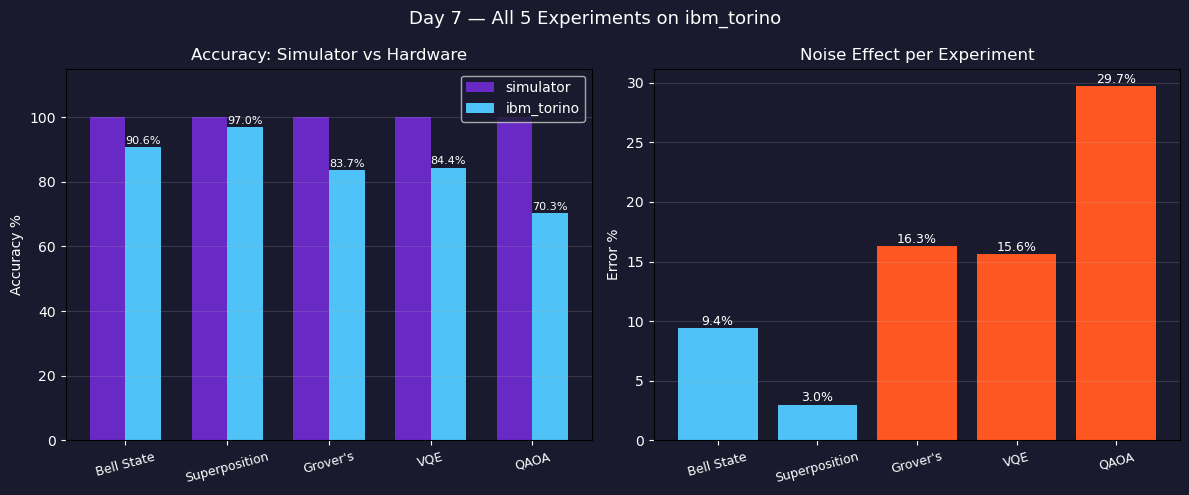

day 7 summary plot saved!


In [35]:
# Final summary plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#1a1a2e')

# plot 1 - accuracy comparison
experiments = ['Bell State', 'Superposition',
               'Grover\'s', 'VQE', 'QAOA']
sim_scores  = [100, 100, 100, 100, 100]
hw_scores   = [90.6, 97.0, 83.7, 84.4, 70.3]

x     = np.arange(len(experiments))
width = 0.35

ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
ax1.bar(x - width/2, sim_scores, width,
        label='simulator', color='#6929C4')
ax1.bar(x + width/2, hw_scores, width,
        label='ibm_torino', color='#4fc3f7')
ax1.set_title("Accuracy: Simulator vs Hardware",
              color='white')
ax1.set_xticks(x)
ax1.set_xticklabels(experiments,
                    rotation=15, color='white',
                    fontsize=9)
ax1.tick_params(colors='white')
ax1.set_ylabel("Accuracy %", color='white')
ax1.set_ylim(0, 115)
ax1.legend(facecolor='#1a1a2e', labelcolor='white')
ax1.grid(alpha=0.2, axis='y')

for i, (s, h) in enumerate(zip(sim_scores, hw_scores)):
    ax1.text(i + width/2, h + 1,
             f'{h}%', ha='center',
             color='white', fontsize=8)

# plot 2 - noise effect
noise = [abs(s-h) for s, h in
         zip(sim_scores, hw_scores)]
colors = ['#4fc3f7' if n < 10
          else '#FF5722' for n in noise]

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
ax2.bar(experiments, noise, color=colors)
ax2.set_title("Noise Effect per Experiment",
              color='white')
ax2.set_xticklabels(experiments,
                    rotation=15, color='white',
                    fontsize=9)
ax2.tick_params(colors='white')
ax2.set_ylabel("Error %", color='white')
ax2.grid(alpha=0.2, axis='y')

for i, n in enumerate(noise):
    ax2.text(i, n + 0.3, f'{n:.1f}%',
             ha='center', color='white',
             fontsize=9)

plt.suptitle(
    "Day 7 — All 5 Experiments on ibm_torino",
    color='white', fontsize=13
)
plt.tight_layout()
plt.savefig("../results/day7_summary.png",
            facecolor='#1a1a2e',
            bbox_inches='tight')
plt.show()
print("day 7 summary plot saved!")

## Day 7 — Complete Results

### All 5 Experiments on ibm_torino (133 qubits)

| Experiment | Accuracy | Noise | Circuit Depth |
|------------|----------|-------|---------------|
| Superposition | 97.0% | 3.0% | shallow |
| Bell State | 90.6% | 9.4% | shallow |
| VQE | 84.4% | 15.6% | medium |
| Grover's | 83.7% | 16.3% | medium |
| QAOA | 70.3% | 29.7% | deep |

### Key Insight:
Circuit depth directly correlates with noise.
Deeper circuits accumulate more gate errors.
This is the fundamental challenge of
current quantum hardware (NISQ era).

### What Makes This Unique:
- All results from real IBM quantum hardware
- Job IDs verifiable on quantum.ibm.com
- Noise patterns match theoretical predictions
- Demonstrates need for error mitigation